## 04 - Conditional Graph

In this notebook we'll do the following:
1. Implement conditional logic to route flow of data to different nodes
2. Design multiple nodes to perform different operations, like **Addition** and **Subraction**
3. Create a **router node** to handle the decision-making and control graph flow (use `add_conditional_edges()`)

In [1]:
from typing import TypedDict, List, Any
from langgraph.graph import StateGraph, START, END

In [2]:
# Step 1: define the graph state
# define the state that will be passed around
# the graph - it should be an instance of TypedDict
class State(TypedDict):
    op1: int  # left operator
    op2: int  # right operator
    operator: str  # one of ['+', '-', '/'. '*']
    result: float  # will hold op1 operator op2 (e.g. op1 + op2)

In [3]:
# Step 2: build the nodes (functions)
import math


def addition(state: State) -> dict[str, Any]:
    """this performs the addition operation"""
    return {"result": state["op1"] + state["op2"]}


def subtraction(state: State) -> dict[str, Any]:
    """this performs the subtraction operation"""
    return {"result": state["op1"] - state["op2"]}


def multiplication(state: State) -> dict[str, Any]:
    """this performs the multiplication operation"""
    return {"result": state["op1"] * state["op2"]}


def division(state: State) -> dict[str, Any]:
    """this performs the division operation"""
    return {"result": math.nan if state["op2"] == 0 else (state["op1"] / state["op2"])}


def op_router(state: State) -> str:
    """route to correct operation node"""
    return state["operator"]

In [4]:
# build out our graph
builder = StateGraph(State)
builder.add_node("addition", addition)
builder.add_node("subtraction", subtraction)
builder.add_node("multiplication", multiplication)
builder.add_node("division", division)
# special pass-through node (take state and pass it along as-is)
builder.add_node("router", lambda state: state)

# add edges (define structure)
builder.add_edge(START, "router")
builder.add_conditional_edges(
    "router",  # from router go to op_router
    op_router,  # and based on value returned from op_router
    {
        # this is like a switch(op_router()) call
        # case "+" -> "addition" etc.
        "+": "addition",
        "-": "subtraction",
        "/": "division",
        "*": "multiplication",
    },
)
# and from all of those to END
builder.add_edge(["addition", "subtraction", "division", "multiplication"], END)
graph = builder.compile()

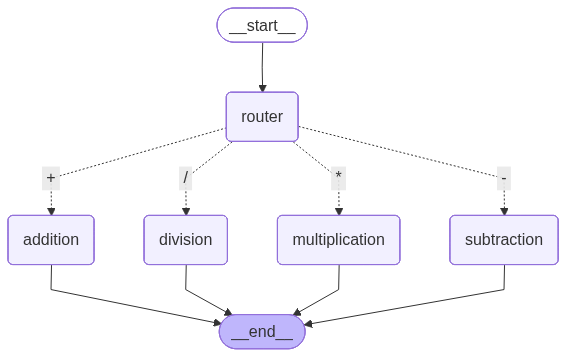

In [5]:
# and let's see how our
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# now invoke the graph
# NOTE: the graph is a Runnable, so it has the invoke() function defined
from rich.console import Console

console = Console()

states = [
    # let's try with different states
    State(op1=25, op2=76, operator="+"),
    State(op1=25, op2=76, operator="-"),
    State(op1=25, op2=5, operator="*"),
    State(op1=25, op2=5, operator="/"),
    State(op1=25, op2=0, operator="/"),
]

for state in states:
    response = graph.invoke(state)
    console.print(response)

{'op1': 25, 'op2': 76, 'operator': '+', 'result': 101}

{'op1': 25, 'op2': 76, 'operator': '-', 'result': -51}

{'op1': 25, 'op2': 5, 'operator': '*', 'result': 125}

{'op1': 25, 'op2': 5, 'operator': '/', 'result': 5.0}

{'op1': 25, 'op2': 0, 'operator': '/', 'result': nan}

### Exercise 
Your Task:
1. Build a 2 router graph as shown in the image below
2. The first router either adds/subtracts number1 & number2 and saves result in finalNumber (in State)
3. The second router either adds/subtracts number2 & number4 and saves result in finalNumber2 (in State)

![Plot](images/04_Ex_conditional_graph.png)


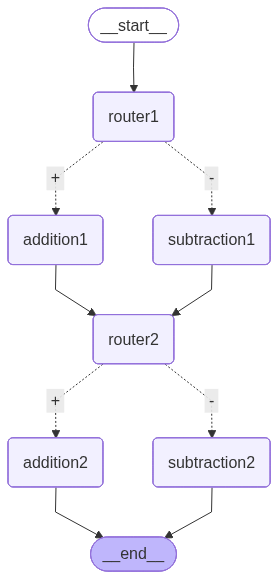

In [9]:
# Step 1: define graph state
from typing import TypedDict, List, Any
from langgraph.graph import StateGraph, START, END
from typing import List


# Step1: define the graph state
class ExState(TypedDict):
    number1: int
    number2: int
    operator1: str  # either '+' or '-'
    finalNumber: int
    number3: int
    number4: int
    operator2: str  # either '+' or '-'
    finalNumber2: int


# Step 2: define the node(s)
def addition1(state: ExState) -> dict[str, Any]:
    """does the operation finalNumber = number1 + number2"""
    return {"finalNumber": state["number1"] + state["number2"]}


def subtraction1(state: ExState) -> dict[str, Any]:
    """does the operation finalNumber = number1 - number2"""
    return {"finalNumber": state["number1"] - state["number2"]}


def op_router1(state: ExState) -> str:
    return state["operator1"]


def addition2(state: ExState) -> dict[str, Any]:
    """does the operation finalNumber2 = number3 + number4"""
    print("addition2 called")
    return {"finalNumber2": state["number3"] + state["number4"]}


def subtraction2(state: ExState) -> dict[str, Any]:
    """does the operation finalNumber2 = number3 - number4"""
    print("subtraction2 called")
    return {"finalNumber2": state["number3"] - state["number4"]}


def op_router2(state: ExState) -> str:
    return state["operator2"]


# Step 3: build the graph
builder = StateGraph(ExState)
builder.add_node("router1", lambda state: state)
builder.add_node("addition1", addition1)
builder.add_node("subtraction1", subtraction1)
builder.add_node("router2", lambda state: state)
builder.add_node("addition2", addition2)
builder.add_node("subtraction2", subtraction2)
# add edges (define structure)
builder.add_edge(START, "router1")
builder.add_conditional_edges(
    "router1",
    op_router1,
    {
        "+": "addition1",
        "-": "subtraction1",
    },
)
# NOTE: while following line IS valid, it will not work!
# This line implies router2 would only fire after BOTH addition1
# AND subtraction1 complete.  But only one of them ever runs,
# so router2 was never reached.

# builder.add_edge(["addition1", "subtraction1"], "router2")

# FIX: use separate edges instead of a list — a list creates a fan-in join,
builder.add_edge("addition1", "router2")
builder.add_edge("subtraction1", "router2")

builder.add_conditional_edges(
    "router2",
    op_router2,
    {
        "+": "addition2",
        "-": "subtraction2",
    },
)
# here it would be ok to the following line
# because END "firing" is irrelevent!
builder.add_edge(["addition2", "subtraction2"], END)

graph = builder.compile()

# and let's see how our graph looks
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
# Step 4: invoke the graph
from rich.console import Console

console = Console()
states = [
    ExState(
        number1=20, number2=45, operator1="+", number3=75, number4=34, operator2="-"
    ),
    ExState(
        number1=20, number2=45, operator1="-", number3=75, number4=34, operator2="+"
    ),
]
for state in states:
    response = graph.invoke(state)
    console.print(f"Invoking graph with {state}")
    console.print(f"Result -> {response}")

subtraction2 called


Invoking graph with {'number1': 20, 'number2': 45, 'operator1': '+', 'number3': 75, 'number4': 34, 'operator2': 
'-'}

Result -> {'number1': 20, 'number2': 45, 'operator1': '+', 'finalNumber': 65, 'number3': 75, 'number4': 34, 
'operator2': '-', 'finalNumber2': 41}

addition2 called


Invoking graph with {'number1': 20, 'number2': 45, 'operator1': '-', 'number3': 75, 'number4': 34, 'operator2': 
'+'}

Result -> {'number1': 20, 'number2': 45, 'operator1': '-', 'finalNumber': -25, 'number3': 75, 'number4': 34, 
'operator2': '+', 'finalNumber2': 109}